# Notebook 02 — Tolerant Retrieval (Spell Correction)

This notebook selects 10 queries, introduces intentional spelling errors, and measures the effect of the spell-correction module on retrieval performance.

In [1]:
import sys, os, json, time, re
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from core.indexer import (
    load_cranfield, build_inverted_index, build_kgram_index, preprocess
)
from core.models import rank
from core.spellcheck import correct_query, set_doc_frequencies
from core.metrics import evaluate_all, mean_average_precision, mean_reciprocal_rank

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load best params from tuning
best_params_path = os.path.join(RESULTS_DIR, 'best_params.json')
if os.path.exists(best_params_path):
    with open(best_params_path) as f:
        best_params = json.load(f)
    print(f'Loaded best params: {best_params}')
else:
    best_params = {'BM25': {'k1': 1.2, 'b': 0.75}, 'QLM (JM)': {'lam': 0.4}, 'QLM (Dirichlet)': {'mu': 1500.0}}
    print('Using default params (run 01_evaluation first for tuned params)')

Loaded best params: {'BM25': {'k1': 2.0, 'b': 0.75}, 'QLM (JM)': {'lam': 0.3}, 'QLM (Dirichlet)': {'mu': 250.0}}


In [2]:
docs, queries, qrels = load_cranfield()
inverted_index, doc_lengths, avg_dl, N, tf_raw, vocabulary = build_inverted_index(docs)
kgram_index = build_kgram_index(vocabulary, k=2)
set_doc_frequencies(inverted_index, vocabulary)

print(f'Vocabulary size: {len(vocabulary)} (unstemmed terms)')
print(f'K-gram entries: {len(kgram_index)}')

Vocabulary size: 7352 (unstemmed terms)
K-gram entries: 750


## 1. Define Misspelled Queries

We define a dictionary of realistic misspellings for domain-specific words, then select 10 queries that contain at least one of these words so that every query is actually affected by the misspelling.

In [3]:
# Misspelling dictionary: correct -> wrong
replacements = {
    'similarity': 'similrity',
    'aerodynamic': 'aerodinamic',
    'aerodynamics': 'aerodinamics',
    'boundary': 'boundry',
    'layer': 'layr',
    'theory': 'theroy',
    'pressure': 'presure',
    'distribution': 'distribtion',
    'experimental': 'experimetal',
    'structural': 'structral',
    'analysis': 'analisys',
    'temperature': 'temprature',
    'transfer': 'tranfer',
    'turbulent': 'turbulnt',
    'velocity': 'velocty',
    'compressible': 'compresible',
    'stability': 'stabilty',
    'supersonic': 'supersonc',
    'hypersonic': 'hypersonc',
    'flow': 'flw',
    'heat': 'haet',
    'shock': 'shok',
    'cylinder': 'cylindr',
    'viscous': 'viscus',
    'conduction': 'conducton',
    'flutter': 'fluter',
    'equations': 'equatons',
    'laminar': 'lamnar',
}

# Find queries that contain at least one replaceable word
def apply_misspellings(text, replacements):
    misspelled = text
    changed = False
    for correct, wrong in replacements.items():
        if correct in misspelled.lower():
            misspelled = re.sub(re.escape(correct), wrong, misspelled, flags=re.IGNORECASE)
            changed = True
    return misspelled, changed

# Select 10 queries that will actually be affected
affected_queries = []
for qid, qtext in sorted(queries.items()):
    _, changed = apply_misspellings(qtext, replacements)
    if changed:
        affected_queries.append(qid)

# Pick 10 spread across the query set
step = max(1, len(affected_queries) // 10)
selected_qids = affected_queries[::step][:10]
print(f'Total queries affected by misspellings: {len(affected_queries)}')
print(f'Selected query IDs: {selected_qids}')

Total queries affected by misspellings: 171
Selected query IDs: [1, 24, 44, 62, 80, 109, 133, 157, 176, 205]


In [4]:
# Build misspelled versions
misspelled_queries = {}
for qid in selected_qids:
    original = queries[qid]
    misspelled, _ = apply_misspellings(original, replacements)
    misspelled_queries[qid] = misspelled

print('Misspelled queries:')
for qid in selected_qids:
    orig = queries[qid][:60]
    mis = misspelled_queries[qid][:60]
    print(f'  Q{qid}:')
    print(f'    Original:    {orig}...')
    print(f'    Misspelled:  {mis}...')

Misspelled queries:
  Q1:
    Original:    what similarity laws must be obeyed when constructing aeroel...
    Misspelled:  what similrity laws must be obeyed when constructing aeroela...
  Q24:
    Original:    what are the factors which influence the time required to in...
    Misspelled:  what are the factors which influence the time required to in...
  Q44:
    Original:    what are the details of the rigorous kinetic theory of gases...
    Misspelled:  what are the details of the rigorous kinetic theroy of gases...
  Q62:
    Original:    how far around a cylinder and under what conditions of flow,...
    Misspelled:  how far around a cylindr and under what conditions of flw,  ...
  Q80:
    Original:    are methods of measuring aerodynamic derivatives available w...
    Misspelled:  are methods of measuring aerodinamic derivatives available w...
  Q109:
    Original:    panels subjected to aerodynamic heating ....
    Misspelled:  panels subjected to aerodinamic haeting ....
  Q1

## 2. Run Retrieval: With and Without Spell Correction

In [5]:
MODEL = 'BM25'
model_params = best_params.get('BM25', {'k1': 1.2, 'b': 0.75})
TOP_K = 100
K = 10

# --- Run with ORIGINAL queries (ground truth) ---
results_original = {}
for qid in selected_qids:
    q_tokens = preprocess(queries[qid])
    ranked = rank(MODEL, q_tokens, inverted_index, tf_raw,
                  doc_lengths, avg_dl, N, top_k=TOP_K, **model_params)
    results_original[qid] = [doc_id for doc_id, _ in ranked]

# --- Run with MISSPELLED queries, spell correction OFF ---
results_misspelled_off = {}
for qid in selected_qids:
    q_tokens = preprocess(misspelled_queries[qid])
    ranked = rank(MODEL, q_tokens, inverted_index, tf_raw,
                  doc_lengths, avg_dl, N, top_k=TOP_K, **model_params)
    results_misspelled_off[qid] = [doc_id for doc_id, _ in ranked]

# --- Run with MISSPELLED queries, spell correction ON ---
results_misspelled_on = {}
corrections_log = {}
for qid in selected_qids:
    corrected_text, was_corrected = correct_query(
        misspelled_queries[qid], kgram_index, vocabulary, k=2)
    corrections_log[qid] = {
        'original': queries[qid],
        'misspelled': misspelled_queries[qid],
        'corrected': corrected_text,
        'was_corrected': was_corrected,
    }
    q_tokens = preprocess(corrected_text)
    ranked = rank(MODEL, q_tokens, inverted_index, tf_raw,
                  doc_lengths, avg_dl, N, top_k=TOP_K, **model_params)
    results_misspelled_on[qid] = [doc_id for doc_id, _ in ranked]

print('Spell correction log:')
for qid, log in corrections_log.items():
    print(f"  Q{qid}: corrected={log['was_corrected']}")
    if log['was_corrected']:
        print(f"    Misspelled: {log['misspelled'][:60]}")
        print(f"    Corrected:  {log['corrected'][:60]}")

Spell correction log:
  Q1: corrected=True
    Misspelled: what similrity laws must be obeyed when constructing aeroela
    Corrected:  what similarity laws must be opened when constructing aeroel
  Q24: corrected=True
    Misspelled: what are the factors which influence the time required to in
    Corrected:  what are the factors which influence the time required to in
  Q44: corrected=True
    Misspelled: what are the details of the rigorous kinetic theroy of gases
    Corrected:  what are the details of the rigorous kinetic theory of gases
  Q62: corrected=True
    Misspelled: how far around a cylindr and under what conditions of flw,  
    Corrected:  how far around a cylinder and under what conditions of flow 
  Q80: corrected=True
    Misspelled: are methods of measuring aerodinamic derivatives available w
    Corrected:  are methods of measuring aerodynamic derivatives available w
  Q109: corrected=True
    Misspelled: panels subjected to aerodinamic haeting .
    Corrected:  pa

## 3. Compute and Compare Metrics

In [6]:
# Build qrels subset
qrels_subset = {qid: qrels[qid] for qid in selected_qids if qid in qrels}

metrics_original = evaluate_all(results_original, qrels_subset, k=K)
metrics_off = evaluate_all(results_misspelled_off, qrels_subset, k=K)
metrics_on = evaluate_all(results_misspelled_on, qrels_subset, k=K)

print(f"{'Condition':<30s} | {'MAP':>7s} | {'MRR':>7s} | {'P@10':>7s} | {'R@10':>7s} | {'F1@10':>7s}")
print('-' * 85)
for label, m in [('Original query', metrics_original),
                 ('Misspelled (correction OFF)', metrics_off),
                 ('Misspelled (correction ON)', metrics_on)]:
    print(f'{label:<30s} | {m["MAP"]:7.4f} | {m["MRR"]:7.4f} | {m[f"P@{K}"]:7.4f} | '
          f'{m[f"R@{K}"]:7.4f} | {m[f"F1@{K}"]:7.4f}')

Condition                      |     MAP |     MRR |    P@10 |    R@10 |   F1@10
-------------------------------------------------------------------------------------
Original query                 |  0.3277 |  0.7125 |  0.2400 |  0.2922 |  0.2115
Misspelled (correction OFF)    |  0.2704 |  0.6322 |  0.2100 |  0.2422 |  0.1750
Misspelled (correction ON)     |  0.3266 |  0.7125 |  0.2400 |  0.2922 |  0.2115


In [7]:
# Save tolerant retrieval metrics
tolerant_data = {
    'original': metrics_original,
    'misspelled_correction_off': metrics_off,
    'misspelled_correction_on': metrics_on,
    'corrections_log': {str(k): v for k, v in corrections_log.items()},
    'model': MODEL,
    'model_params': model_params,
}
with open(os.path.join(RESULTS_DIR, 'tolerant_metrics.json'), 'w') as f:
    json.dump(tolerant_data, f, indent=2)
print('Saved tolerant_metrics.json')

Saved tolerant_metrics.json


## 4. Visualisation — Grouped Bar Chart

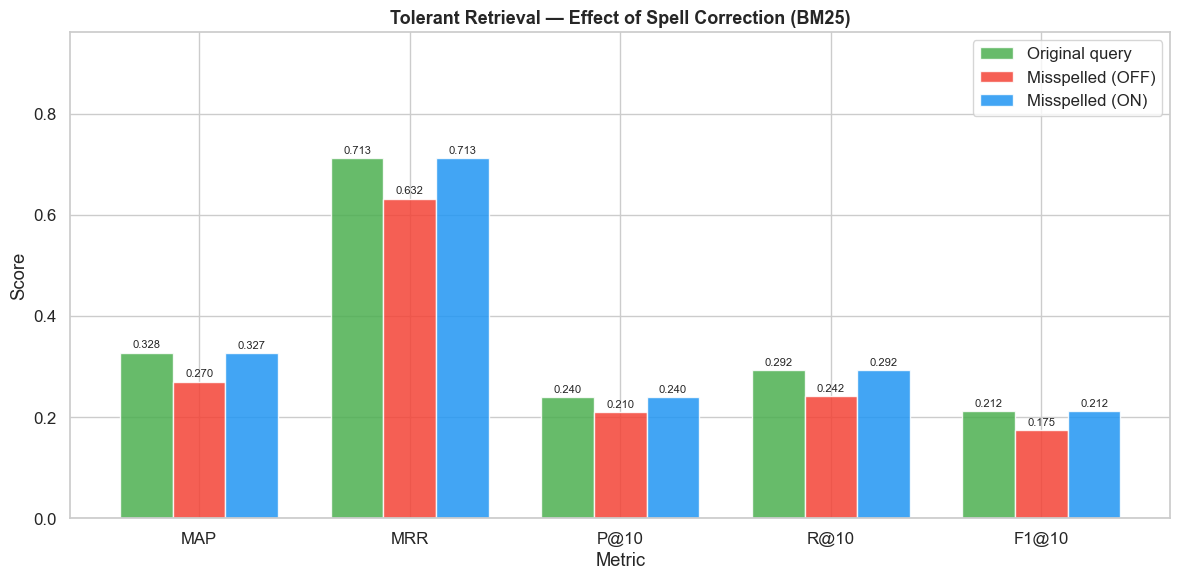

Saved tolerant_comparison.png


In [8]:
sns.set_theme(style='whitegrid', font_scale=1.1)

metric_keys = ['MAP', 'MRR', f'P@{K}', f'R@{K}', f'F1@{K}']
conditions = ['Original query', 'Misspelled (OFF)', 'Misspelled (ON)']
all_vals = [metrics_original, metrics_off, metrics_on]
colors_cond = ['#4CAF50', '#F44336', '#2196F3']

x = np.arange(len(metric_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (cond, vals, col) in enumerate(zip(conditions, all_vals, colors_cond)):
    bar_vals = [vals[mk] for mk in metric_keys]
    bars = ax.bar(x + i * width, bar_vals, width, label=cond, color=col, alpha=0.85)
    for bar, v in zip(bars, bar_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title(f'Tolerant Retrieval — Effect of Spell Correction ({MODEL})',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_keys)
ax.legend()
ax.set_ylim(0, max(max(v[mk] for mk in metric_keys) for v in all_vals) * 1.35)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'tolerant_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved tolerant_comparison.png')

## 5. Per-Query Analysis

In [9]:
from core.metrics import average_precision, reciprocal_rank, precision_at_k

per_query = []
for qid in selected_qids:
    if qid not in qrels:
        continue
    rel = qrels[qid]
    ap_orig = average_precision(results_original[qid], rel)
    ap_off = average_precision(results_misspelled_off[qid], rel)
    ap_on = average_precision(results_misspelled_on[qid], rel)
    per_query.append({
        'qid': qid,
        'AP_original': round(ap_orig, 4),
        'AP_correction_off': round(ap_off, 4),
        'AP_correction_on': round(ap_on, 4),
        'improvement': round(ap_on - ap_off, 4),
    })

from IPython.display import display
import pandas as pd
df_pq = pd.DataFrame(per_query)
display(df_pq)
df_pq.to_csv(os.path.join(RESULTS_DIR, 'tolerant_per_query.csv'), index=False)
print('\nSaved tolerant_per_query.csv')

,qid,AP_original,AP_correction_off,AP_correction_on,improvement
0,1,0.2805,0.2098,0.2690,0.0592
1,24,0.6813,0.5341,0.6813,0.1472
2,44,0.0000,0.0000,0.0000,0.0000
3,62,0.0139,0.0076,0.0139,0.0063
4,80,0.2219,0.2302,0.2219,-0.0083
5,109,0.0515,0.0164,0.0515,0.0350
6,133,0.4036,0.2786,0.4036,0.1250
7,157,0.3816,0.3755,0.3816,0.0062
8,176,0.2432,0.1353,0.2432,0.1079
9,205,1.0000,0.9167,1.0000,0.0833



Saved tolerant_per_query.csv


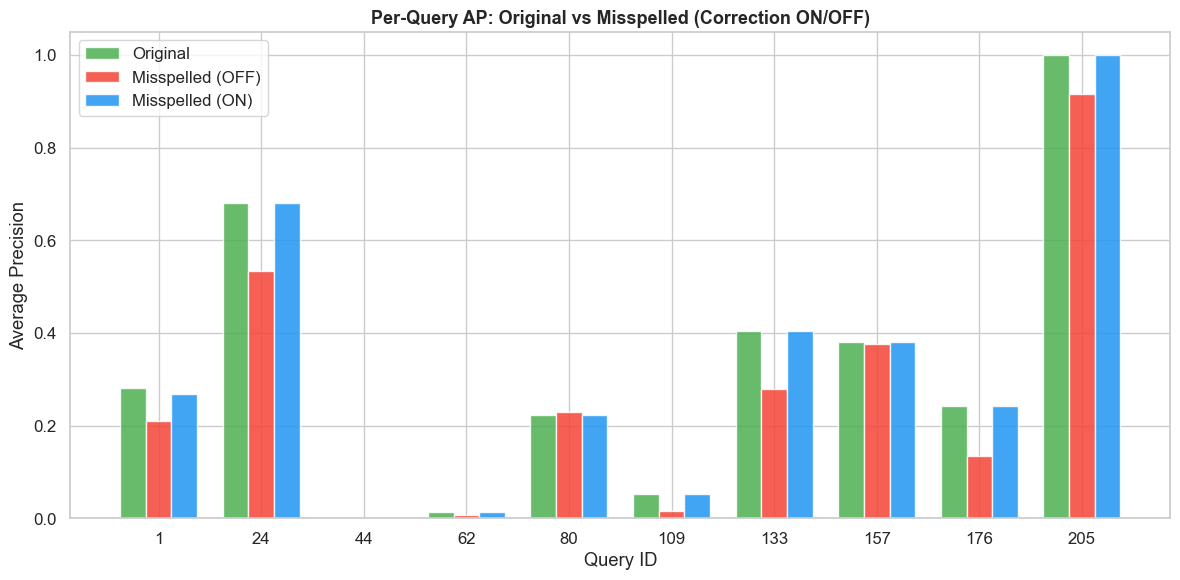

Saved tolerant_per_query.png


In [10]:
# Per-query AP comparison chart
fig, ax = plt.subplots(figsize=(12, 6))
qids = [str(r['qid']) for r in per_query]
x = np.arange(len(qids))
width = 0.25

ax.bar(x - width, [r['AP_original'] for r in per_query], width, label='Original', color='#4CAF50', alpha=0.85)
ax.bar(x, [r['AP_correction_off'] for r in per_query], width, label='Misspelled (OFF)', color='#F44336', alpha=0.85)
ax.bar(x + width, [r['AP_correction_on'] for r in per_query], width, label='Misspelled (ON)', color='#2196F3', alpha=0.85)

ax.set_xlabel('Query ID')
ax.set_ylabel('Average Precision')
ax.set_title('Per-Query AP: Original vs Misspelled (Correction ON/OFF)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(qids)
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'tolerant_per_query.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved tolerant_per_query.png')